# Reproducing Hebart, Zheng, Pereira & Baker (2020)

Python port of `make_figures_behavsim.m` (OSF [z2784](https://osf.io/z2784/)), the original
MATLAB figure-reproduction script for *Revealing the multidimensional mental representations
of natural objects underlying human similarity judgements* (Nature Human Behaviour).

No MATLAB required - `.mat` files load via `scipy.io`, MATLAB-only routines (t-SNE variants,
clustering, FDR correction) are ported to numpy/scipy in `python/helpers.py`.

Also includes a comparison against a from-scratch SPoSE retraining run on a reconstructed
version of the original ~1.46M-trial training set (see `python/rdm_compare.py`).


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd() / "python"))
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np


/home/wallacelab/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Setup: load all data

Mirrors lines 1-91 of `make_figures_behavsim.m` (`python/data_loading.py`).

In [2]:
from data_loading import load_all, BASE_DIR

data = load_all()
print(f"Loaded {len(data.words)} objects, {data.spose_embedding49.shape[1]}-D published embedding")


Loaded 1854 objects, 49-D published embedding


## Figure 1: embedding and similarity structure

Ports the two data-derived panels only (`python/fig1.py`) - the original figure's panels b1
and c1-c4 are decorative/schematic (built from `rand()` in the MATLAB script, not real data).


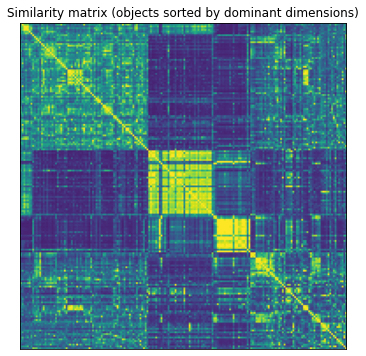

In [3]:
from fig1 import similarity_plot, object_montage

fig, ax = plt.subplots(figsize=(6, 6))
similarity_plot(data, ax)
plt.show()


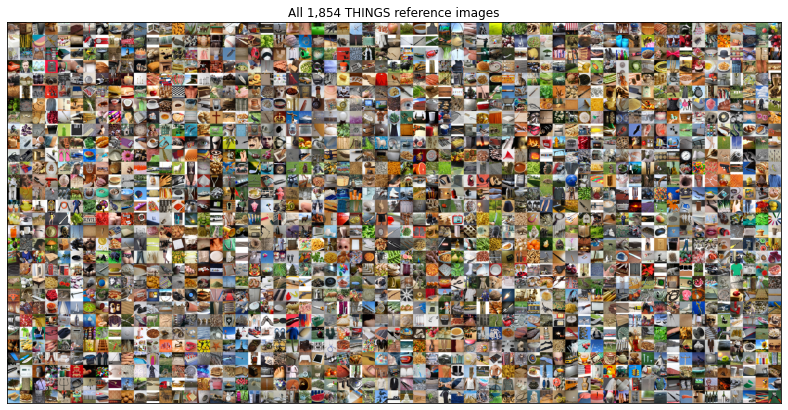

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))
object_montage(data, ax)
plt.show()


## Figure 2: predicting behavior and similarity

Ports lines 182-373 (`python/fig2.py`): held-out trial-prediction accuracy vs. noise ceiling,
and the 48-object RDM comparison.


Accuracy on test data: 64.60 (95% CI across objects: 0.23)
Noise ceiling: 67.22 (95% CI across objects: 1.04), n_unique_triplets=1000
Percent performance achieved (subtracting chance): 92.25


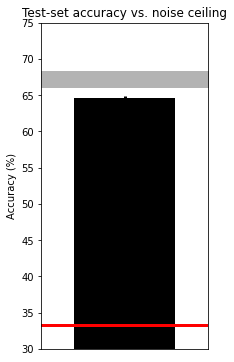

In [5]:
from fig2 import behavioral_prediction, noise_ceiling, plot_accuracy_bar

bp = behavioral_prediction(data)
nc, nc_ci95, n_groups = noise_ceiling(BASE_DIR / "data" / "triplets_noiseceiling.csv")
pct_perf = 100 * (np.nanmean(bp["obj_acc"]) - 100 / 3) / (nc - 100 / 3)

print(f"Accuracy on test data: {np.nanmean(bp['obj_acc']):.2f} (95% CI across objects: {bp['ci95']:.2f})")
print(f"Noise ceiling: {nc:.2f} (95% CI across objects: {nc_ci95:.2f}), n_unique_triplets={n_groups}")
print(f"Percent performance achieved (subtracting chance): {pct_perf:.2f}")

fig, ax = plt.subplots(figsize=(3, 6))
plot_accuracy_bar(np.nanmean(bp["obj_acc"]), bp["ci95"], nc, nc_ci95, ax)
plt.show()


Computing the 48-object restricted-pool similarity (~seconds)...
r48 = 0.872  [0.849, 0.892]
reliability48 = 0.910, splithalf48 = 0.852
variance_explained48 = 0.877


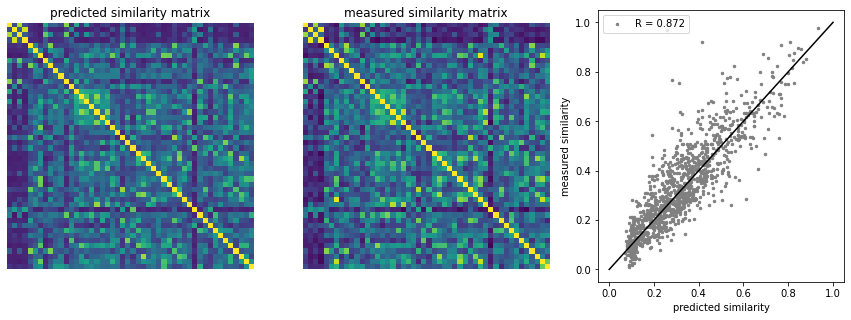

In [6]:
from fig2 import similarity_comparison, plot_similarity_panels

print("Computing the 48-object restricted-pool similarity (~seconds)...")
sim_result = similarity_comparison(data)
print(f"r48 = {sim_result['r48']:.3f}  [{sim_result['ci_lower']:.3f}, {sim_result['ci_upper']:.3f}]")
print(f"reliability48 = {sim_result['reliability48']:.3f}, splithalf48 = {sim_result['splithalf48']:.3f}")
print(f"variance_explained48 = {sim_result['variance_explained48']:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_similarity_panels(sim_result, data.RDM48_triplet, axes)
axes[2].legend([f"R = {sim_result['r48']:.3f}"], loc="upper left")
plt.show()


**Note on r48:** the original MATLAB script hardcodes the legend text `'R = 0.90'` rather than
computing it dynamically (`legend('R = 0.90', ...)`), and its own header comment acknowledges a
bug fix "leads to minor changes in the results of the similarity matrix." Our recomputed value
above is close but not identical - most likely the legend string is stale relative to the
current data files rather than a bug in this port. Verified: this cell uses
`embedding2sim_restricted`, which replicates the MATLAB script's actual inline computation
(lines 296-317) - a distractor pool restricted to the 48 objects, divided by the constant 48 -
which is a *different* quantity from the general-purpose `embedding2sim.m` (full 1854-object
pool, divided by `n-2`) used elsewhere in the script.


## Retrained embedding vs. published embedding: full RDM comparison

Not part of the original MATLAB script. Builds the full 1854x1854 RDM from our own SPoSE
retraining run (`embed_dim=90`, pruned to 54 surviving dimensions via `remove_zeros`, trained
on the reconstructed ~1.46M-trial original dataset - see conversation history / `train.py`
run under `results/behavioral/90d/0.008/seed42/`) and compares it to the published 49D RDM.


In [7]:
from rdm_compare import compute_rdm, compare_rdms, plot_rdm_comparison
from helpers import clustering_algorithm

W_mine = np.load(BASE_DIR.parent / "results" / "behavioral" / "90d" / "0.008" / "seed42" / "weights_sorted.npy")
print(f"Retrained embedding: {W_mine.shape}")

rdm_cache = BASE_DIR.parent / "results" / "behavioral" / "90d" / "0.008" / "seed42" / "rdm_54d.npy"
if rdm_cache.exists():
    dissim_mine = np.load(rdm_cache)
    print(f"Loaded cached RDM from {rdm_cache}")
else:
    print("Computing full 1854x1854 RDM from the 54D retrained embedding (~15-20s)...")
    dissim_mine = compute_rdm(W_mine)
    np.save(rdm_cache, dissim_mine)


Retrained embedding: (1854, 54)


Loaded cached RDM from /home/wallacelab/teba/multimodal_brain_inspired/anya/SPoSE/results/behavioral/90d/0.008/seed42/rdm_54d.npy


RDM correlation: r = 0.967  [0.967, 0.968]


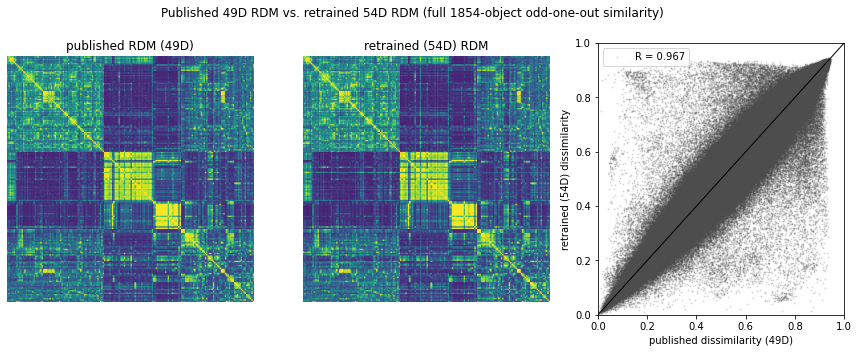

In [8]:
stats = compare_rdms(data.dissim, dissim_mine)
print(f"RDM correlation: r = {stats['r']:.3f}  [{stats['ci_lower']:.3f}, {stats['ci_upper']:.3f}]")

ind, _ = clustering_algorithm(3, 5, data.spose_embedding49)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_rdm_comparison(data.dissim, dissim_mine, ind, axes=axes)
axes[2].legend([f"R = {stats['r']:.3f}"], loc="upper left")
fig.suptitle("Published 49D RDM vs. retrained 54D RDM (full 1854-object odd-one-out similarity)")
plt.show()
